# Rotatividade de Clientes - Customer Churn Analytics

Análise de rotatividade de clientes para uma empresa de telecomunicações.

Esse é um projeto de classificação.

Disponível também em meu <a href='https://github.com/rafaelgfelippe/CustomerChurn'>github</a>.

O conjunto de dados utilizado está disponível <a href='https://www.kaggle.com/blastchar/telco-customer-churn'>neste link</a>.

## 1. Entendimento do Negócio

A EasyNet é uma empresa de telecomunicações que oferece serviços de telefonia, internet e TV por assinatura. Para esse segmento, saber e prever a taxa de cancelamento de serviços é bastante útil, pois há uma grande concorrência nesse mercado.

Atualmente, a taxa de rotatividade de clientes da empresa é de aproximadamente 25%. Visando diminuir esse número, a EasyNet resolveu implementar um projeto para identificar potenciais cancelamentos com antecedência, e assim, promover ações direcionadas para esses clientes a fim de mantê-los na empresa. 

Durante a reunião de alinhamento do projeto, foi estabelecido que a equipe de dados ficará responsável por identificar os clientes mais propensos a abandonar os serviços da empresa e a área de Marketing deverá criar ofertas e planos customizados para esses clientes. Portanto, nesse projeto, nosso objetivo é criar um modelo capaz de responder a seguinte pergunta:

> **Quais clientes estão mais propensos a abandonar os serviços da EasyNet?**

### 1.1 Dicionário de Dados

Em relação ao conjunto de dados, as seguintes informações foram disponibilizadas:

- Os dados estão em formato estruturado e serão disponibilizados em um arquivo "csv".
- A maioria das variáveis são categóricas.

Além disso, também foi disponibilizado o dicionário de dados:

* **`customerID`**: identificação do cliente.
* **`gender`**: gênero do cliente.
* **`SeniorCitizen`**: cliente da terceira idade: 
    - 0 = não.
    - 1 = sim. 
* **`Partner`**: cliente casado:
    - No.
    - Yes.
* **`Dependents`**: cliente possui dependentes:
    - No.
    - Yes.
* **`tenure`**: tempo de contrato do cliente (em meses).
* **`PhoneService`**: serviço telefônico:
    - No.
    - Yes.
* **`MultipleLines`**: múltiplas linhas telefônicas:
    - No.
    - No phone service.
    - Yes.
* **`InternetService`**: tipo de provedor de internet: 
    - DSL.
    - Fiber optic.
    - No.
* **`OnlineSecurity`**: serviço de segurança online:
    - No.
    - No internet service.
    - Yes.
* **`OnlineBackup`**: serviço de backup online:
    - No.
    - No internet service.
    - Yes.
* **`DeviceProtection`**: proteção de dispositivo:
    - No.
    - No internet service.
    - Yes.
* **`TechSupport`**: suporte técnico:
    - No.
    - No internet service.
    - Yes.
* **`StreamingTV`**: serviços de streaming (TV):
    - No.
    - No internet service.
    - Yes.
* **`StreamingMovies`**: serviços de streaming (filmes):
    - No.
    - No internet service.
    - Yes.
* **`Contract`**: tipo do contrato:
    - Month-to-month.       
    - One year.       
    - Two year. 
* **`PaperlessBilling`**: fatura eletrônica:
    - No.
    - Yes.
* **`PaymentMethod`**: método de pagamento:
    - Bank transfer (automatic).   
    - Credit card (automatic).          
    - Electronic check. 
    - Mailed check.
* **`MonthlyCharges`**: valor pago mensal.
* **`TotalCharges`**: valor total já pago pelo cliente.
* **`Churn`**: cancelamento do serviço:
    - No.
    - Yes.

### 1.2 Estratégia da Solução

Como estratégia para a solução do projeto, definimos as seguintes etapas:

- **1. Entendimento do Negócio:** essa etapa é basicamente o que vimos até aqui: especificamos o problema de negócio, entendemos a necessidade do cliente e definimos nossos objetivos.


- **2. Entendimento dos Dados:** nosso objetivo é tratar as principais inconsistências observadas, e realizar uma análise exploratória a fim de entender o que as variáveis representam.


- **3. Engenharia de Atributos:** utilizaremos os dados disponíveis para criar uma nova variável, e assim, facilitar o aprendizado dos modelos. Além disso, também realizaremos a seleção das melhores variáveis.


- **4. Pré-Processamento dos Dados:** aqui, temos como objetivo preparar os dados para a etapa da modelagem preditiva. Iremos dividir os dados em conjuntos de treino e teste e aplicar técnicas como, balanceamento de classes, codificação e normalização de variáveis.


- **5. Modelagem Preditiva**: criaremos modelos utilizando alguns dos principais algoritmos de classificação.


- **6. Comparando os Modelos:** baseado na *ROC AUC*, vamos comparar os modelos criados a fim de selecionar o de melhor desempenho.


- **7. Conclusões Finais:** por fim, entregaremos o resultado final do projeto.

## 2. Entendimento dos Dados

Vamos iniciar o projeto carregando as bibliotecas e o conjunto de dados.

### 2.1 Bibliotecas Necessárias

In [1]:
# Filtragem das mensagens de avisos.
options(warn = -1)
options(dplyr.summarise.inform = FALSE)

# Carregando as bibliotecas. 
library(pacman)

pacman::p_load(caret,
               cowplot,
               dplyr,
               ggcorrplot,
               ggplot2,
               klaR,
               plotROC,
               plyr,
               ROSE,
               stringr)        

In [2]:
# Configurações do notebook.

# Plotagens.
options(repr.plot.width = 10, 
        repr.plot.height = 6, 
        scipen = 999)

# Estilo dos gráficos.
theme_set(theme_minimal())

### 2.2 Tratamento Inicial dos Dados

Nessa etapa, nosso objetivo é realizar uma análise geral no dataset a fim de tratar possíveis inconsistências nos dados.

In [3]:
# Carregando o conjunto de dados.
df <- read.csv('data/Telco-Customer-Churn.csv')

Criar uma cópia do dataset é uma boa prática para não perdermos o conteúdo original durante a manipulação dos dados.

In [4]:
# Cópia do dataset.
df1 <- df

In [5]:
# Dimensão do dataframe.
dim(df1)

[1] 7043   21

O conjunto de dados possui 7043 registros e 21 variáveis.

In [6]:
# Visualizando o dataframe.
head(df1)

customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
9305-CDSKC,Female,0,No,No,8,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.50,Yes


In [7]:
# Informações do dataframe.
str(df1)

'data.frame':	7043 obs. of  21 variables:
 $ customerID      : Factor w/ 7043 levels "0002-ORFBO","0003-MKNFE",..: 5376 3963 2565 5536 6512 6552 1003 4771 5605 4535 ...
 $ gender          : Factor w/ 2 levels "Female","Male": 1 2 2 2 1 1 2 1 1 2 ...
 $ SeniorCitizen   : int  0 0 0 0 0 0 0 0 0 0 ...
 $ Partner         : Factor w/ 2 levels "No","Yes": 2 1 1 1 1 1 1 1 2 1 ...
 $ Dependents      : Factor w/ 2 levels "No","Yes": 1 1 1 1 1 1 2 1 1 2 ...
 $ tenure          : int  1 34 2 45 2 8 22 10 28 62 ...
 $ PhoneService    : Factor w/ 2 levels "No","Yes": 1 2 2 1 2 2 2 1 2 2 ...
 $ MultipleLines   : Factor w/ 3 levels "No","No phone service",..: 2 1 1 2 1 3 3 2 3 1 ...
 $ InternetService : Factor w/ 3 levels "DSL","Fiber optic",..: 1 1 1 1 2 2 2 1 2 1 ...
 $ OnlineSecurity  : Factor w/ 3 levels "No","No internet service",..: 1 3 3 3 1 1 1 3 1 3 ...
 $ OnlineBackup    : Factor w/ 3 levels "No","No internet service",..: 3 1 3 1 1 1 3 1 1 3 ...
 $ DeviceProtection: Factor w/ 3 levels "No","

- A variável **`SeniorCitizen`** foi carregada com o tipo incorreto.

In [8]:
# Convertendo a variável.
df1$SeniorCitizen <- as.factor(df1$SeniorCitizen)

In [9]:
# Verificando registros ausentes.
colSums(is.na(df1))

customerID           gender    SeniorCitizen          Partner 
               0                0                0                0 
      Dependents           tenure     PhoneService    MultipleLines 
               0                0                0                0 
 InternetService   OnlineSecurity     OnlineBackup DeviceProtection 
               0                0                0                0 
     TechSupport      StreamingTV  StreamingMovies         Contract 
               0                0                0                0 
PaperlessBilling    PaymentMethod   MonthlyCharges     TotalCharges 
               0                0                0               11 
           Churn 
               0

- A variável **`TotalCharges`** possui 11 registros ausentes.

In [10]:
# Removendo registros ausentes.
df1 <- df1[complete.cases(df1), ]

In [11]:
# Verificando registros duplicados.
table(duplicated(df1))


FALSE 
 7032 

In [12]:
# Verificando registros únicos.
sapply(df1, function(x) {length(unique(x))})

customerID           gender    SeniorCitizen          Partner 
            7032                2                2                2 
      Dependents           tenure     PhoneService    MultipleLines 
               2               72                2                3 
 InternetService   OnlineSecurity     OnlineBackup DeviceProtection 
               3                3                3                3 
     TechSupport      StreamingTV  StreamingMovies         Contract 
               3                3                3                3 
PaperlessBilling    PaymentMethod   MonthlyCharges     TotalCharges 
               2                4             1584             6530 
           Churn 
               2

Iremos substituir os valores *No phone service* e *No internet service* presentes nas variáveis categóricas pelo valor *No*.

In [13]:
# Substituindo os valores "No phone service".
df1$MultipleLines <- as.factor(mapvalues(df1$MultipleLines, from = c('No phone service'), to = c('No')))

In [14]:
# Substituindo os valores "No internet service".

# Índices das variáveis.
cols_recode <- c(10:15)

# Tratando os registros das variáveis.
for(i in 1: ncol(df1[, cols_recode])){
    df1[, cols_recode][,i] <- as.factor(mapvalues(df1[, cols_recode][,i], from = c('No internet service'), to = c('No')))}

Realizamos uma análise geral nos dados tratando as principais inconsistências observadas, agora, partiremos para uma análise mais detalhada.

### 2.3 Análise Exploratória

#### 2.3.1 Variáveis Categóricas

Verificaremos a taxa de rotatividade baseado nas características dos clientes e nos serviços prestados pela EasyNet.

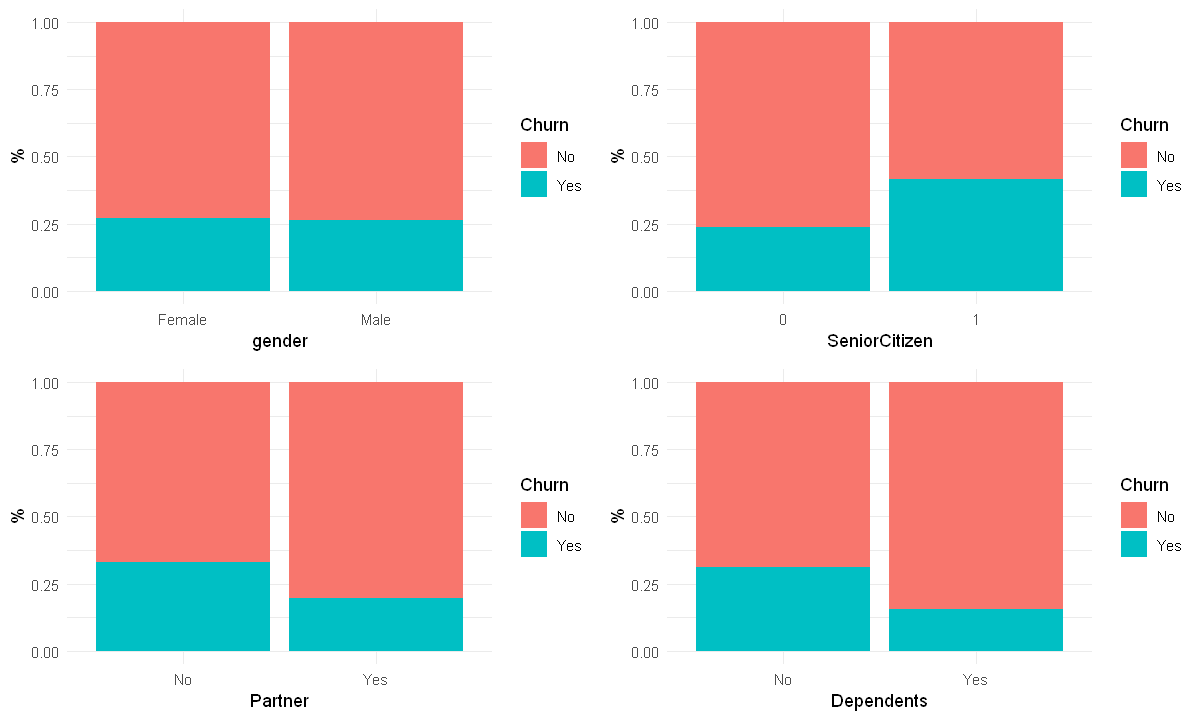

In [15]:
# Churn por características dos clientes.
plot_grid(ggplot(df1, aes(x = gender, fill = Churn)) + geom_bar(position = 'fill') + labs(y = '%'),
          ggplot(df1, aes(x = SeniorCitizen, fill = Churn)) + geom_bar(position = 'fill') + labs(y = '%'),
          ggplot(df1, aes(x = Partner, fill = Churn)) + geom_bar(position = 'fill') + labs(y = '%'),
          ggplot(df1, aes(x = Dependents, fill = Churn)) + geom_bar(position = 'fill') + labs(y = '%') +
          scale_x_discrete(labels = function(x) str_wrap(x, width = 10)), align = 'h')

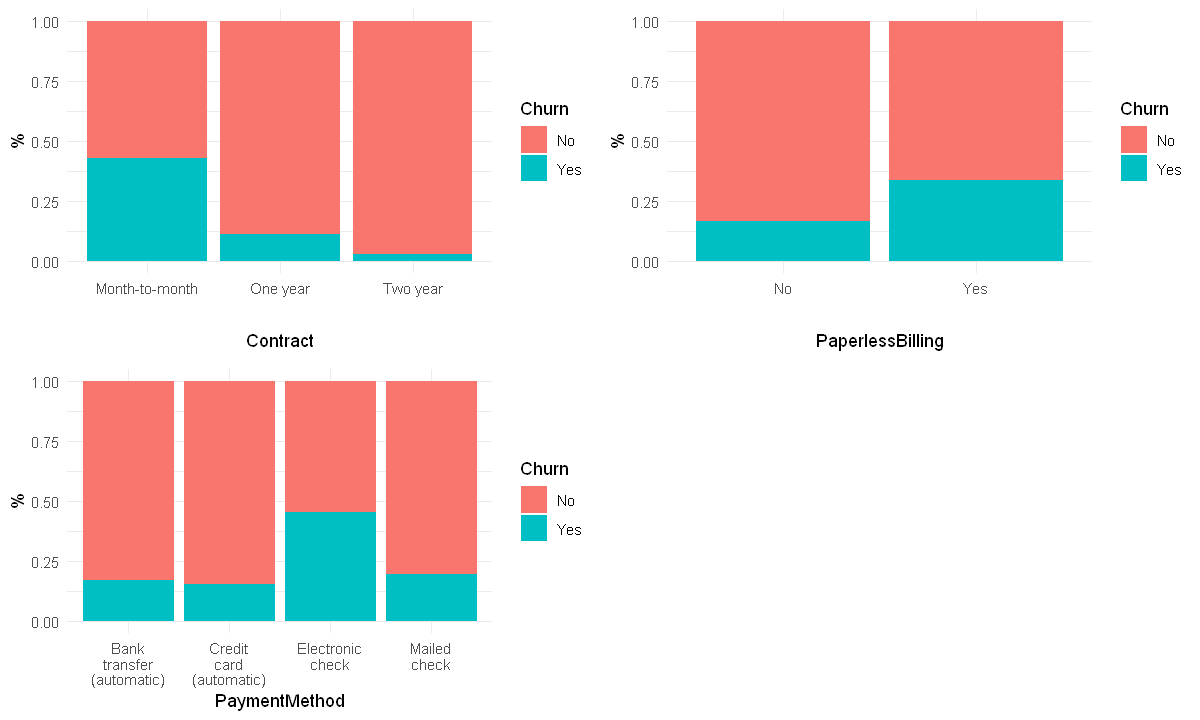

In [16]:
# Churn por informações das contas dos clientes.
plot_grid(ggplot(df1, aes(x = Contract, fill = Churn)) + geom_bar(position = 'fill') + labs(y = '%'), 
          ggplot(df1, aes(x = PaperlessBilling, fill = Churn)) + geom_bar(position = 'fill') + labs(y = '%'),
          ggplot(df1, aes(x = PaymentMethod, fill = Churn)) + geom_bar(position = 'fill') + labs(y = '%') +
          scale_x_discrete(labels = function(x) str_wrap(x, width = 10)), align = 'h')

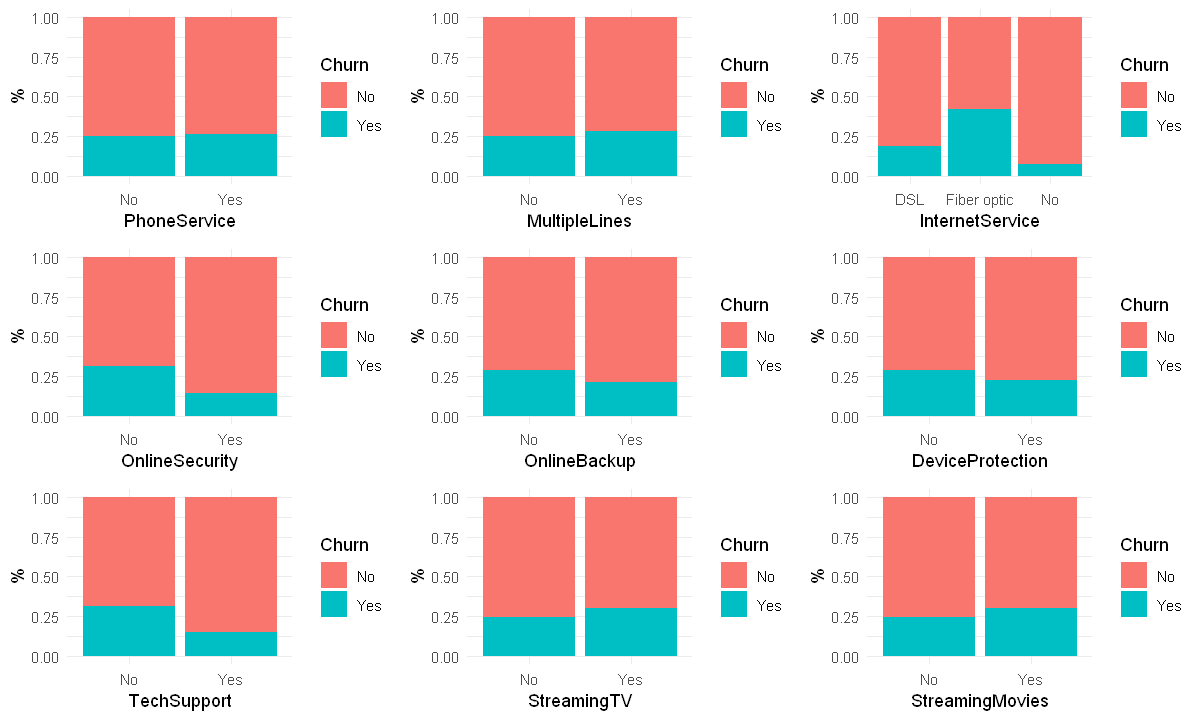

In [17]:
# Churn por serviços da empresa.
plot_grid(ggplot(df1, aes(x = PhoneService, fill = Churn)) + geom_bar(position = 'fill') + labs(y = '%'), 
          ggplot(df1, aes(x = MultipleLines, fill = Churn)) + geom_bar(position = 'fill') + labs(y = '%'),
          ggplot(df1, aes(x = InternetService, fill = Churn)) + geom_bar(position = 'fill') + labs(y = '%'),
          ggplot(df1, aes(x = OnlineSecurity, fill = Churn)) + geom_bar(position = 'fill') + labs(y = '%'),
          ggplot(df1, aes(x = OnlineBackup, fill = Churn)) + geom_bar(position = 'fill') + labs(y = '%'),
          ggplot(df1, aes(x = DeviceProtection, fill = Churn)) + geom_bar(position = 'fill') + labs(y = '%'),
          ggplot(df1, aes(x = TechSupport, fill = Churn)) + geom_bar(position = 'fill') + labs(y = '%'),
          ggplot(df1, aes(x = StreamingTV, fill = Churn)) + geom_bar(position = 'fill') + labs(y = '%'),
          ggplot(df1, aes(x = StreamingMovies, fill = Churn)) + geom_bar(position = 'fill') + labs(y = '%') + 
          scale_x_discrete(labels = function(x) str_wrap(x, width = 10)), align = 'h')

- Algumas variáveis possuem uma distribuição percentual muito parecida, indicando que provavelmente não serão úteis para a modelagem preditiva.

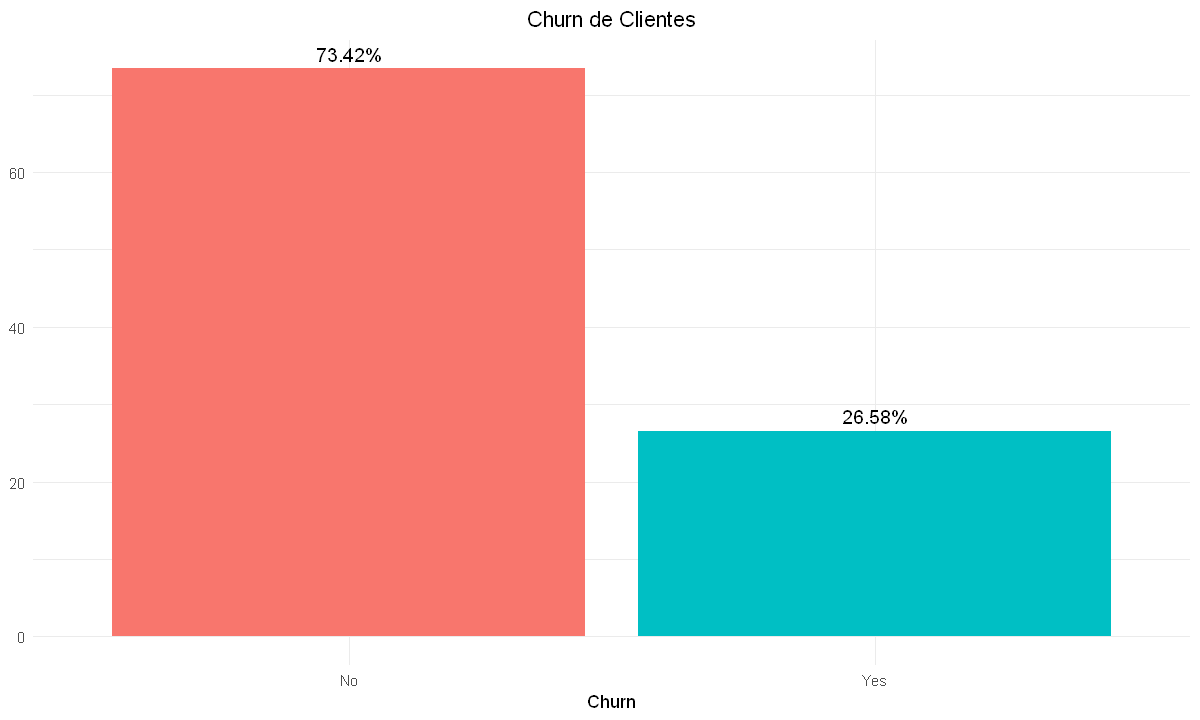

In [18]:
# Churn total de clientes.
df1 %>%
group_by(Churn) %>% 
dplyr::summarise(Number = n()) %>%
mutate(Porcentagem = prop.table(Number) * 100) %>% 
ggplot(aes(Churn, Porcentagem)) + 
geom_col(aes(fill = Churn), show.legend = FALSE) +
labs(title = 'Churn de Clientes', y = NULL) +
theme(plot.title = element_text(hjust = 0.5)) +
geom_text(aes(label = sprintf('%.2f%%', Porcentagem)), vjust = -0.5, size = 4)

#### 2.3.2 Variáveis Numéricas

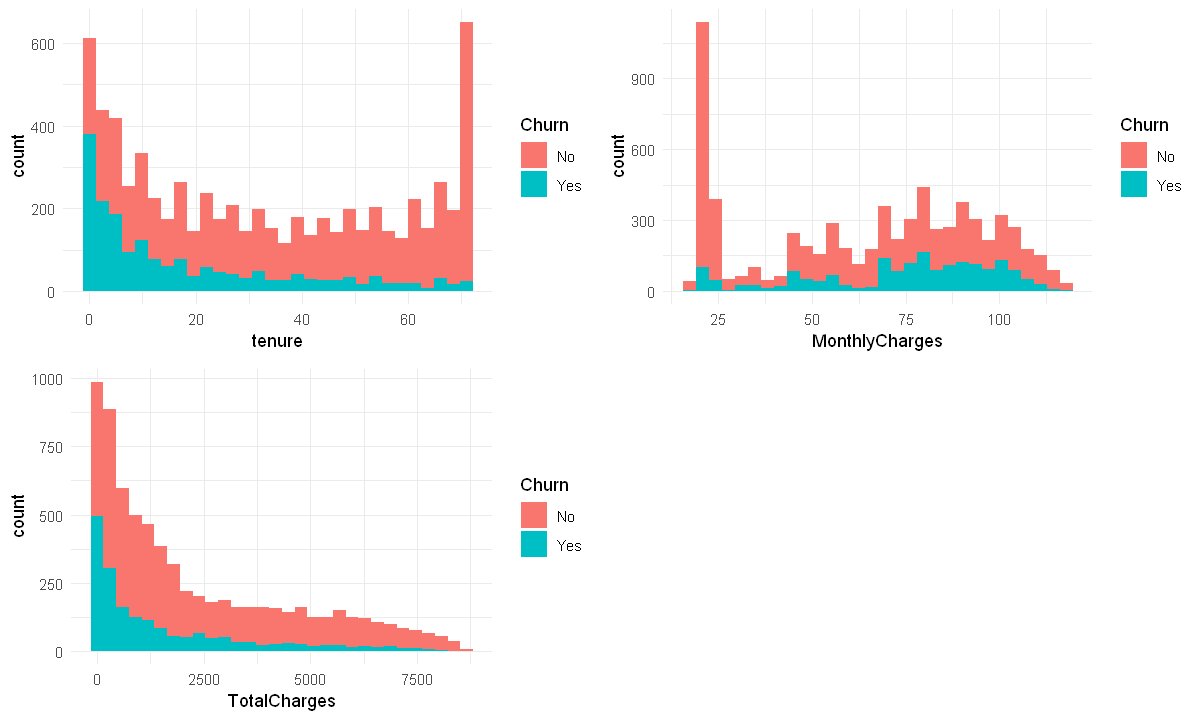

In [19]:
# Churn por tempo de contrato e pagamentos realizados.
plot_grid(ggplot(df1, aes(x = tenure, fill = Churn)) + geom_histogram(bins = 30), 
          ggplot(df1, aes(x = MonthlyCharges, fill = Churn)) + geom_histogram(bins = 30), 
          ggplot(df1, aes(x = TotalCharges, fill = Churn)) + geom_histogram(bins = 30))

- A maior taxa de rotatividade se encontra em clientes com menos tempo de contrato.
- Clientes com pagamentos mensais mais altos possuem maior taxa de rotatividade.

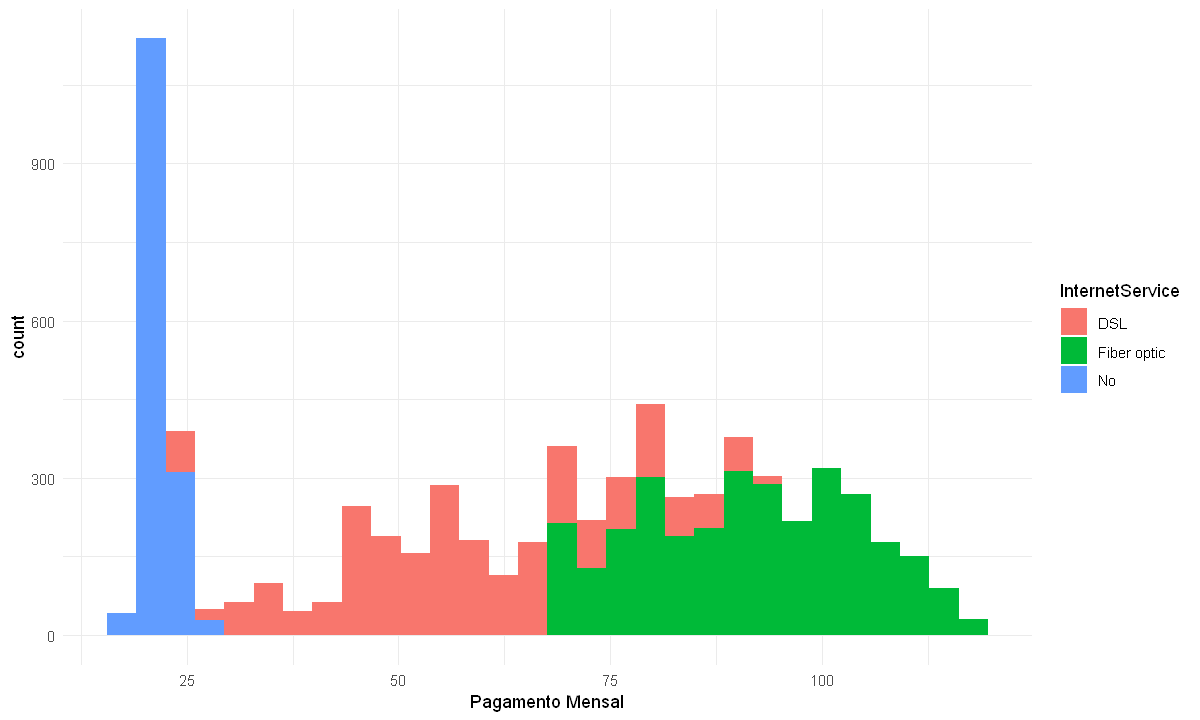

In [20]:
# Pagamento mensal por provedor de internet.
ggplot(df1, aes(x = MonthlyCharges, fill = InternetService)) + geom_histogram(bins = 30) + labs(x = 'Pagamento Mensal')

- Internet por fibra ótica possui os maiores pagamentos mensais, e como já visto, a maior taxa de rotatividade.   

## 3. Engenharia de Atributos

### 3.1 Extração de Variáveis (Feature Extraction)

A etapa de extração de variáveis será constituída na criação da variável **`tenure_group`** seguindo as regras abaixo:

- Clientes com tempo de contrato de 0 a 12 meses receberam o valor **1**.
- Clientes com tempo de contrato de 12 a 24 meses receberam o valor **2**.
- Clientes com tempo de contrato de 24 a 48 meses receberam o valor **3**.
- Clientes com tempo de contrato de 48 a 60 meses receberam o valor **4**.
- Clientes com tempo de contrato de 60 a 72 meses receberam o valor **5**.

In [21]:
# Criando a função.
group_tenure <- function(tenure){
    if (tenure >= 0 & tenure <= 12){
        return(1)
    }else if(tenure > 12 & tenure <= 24){
        return(2)
    }else if (tenure > 24 & tenure <= 48){
        return(3)
    }else if (tenure > 48 & tenure <= 60){
        return(4)
    }else if (tenure > 60){
        return(5)
    }}

In [22]:
# Criando nova variável.
df1$tenure_group <- sapply(df1$tenure, group_tenure)

# Convertendo a variável.
df1$tenure_group <- as.factor(df1$tenure_group)

In [23]:
# Level's da variável.
levels(df1$tenure_group)

[1] "1" "2" "3" "4" "5"

In [24]:
# Contagem de registros.
table(df1$tenure_group)


   1    2    3    4    5 
2175 1024 1594  832 1407 

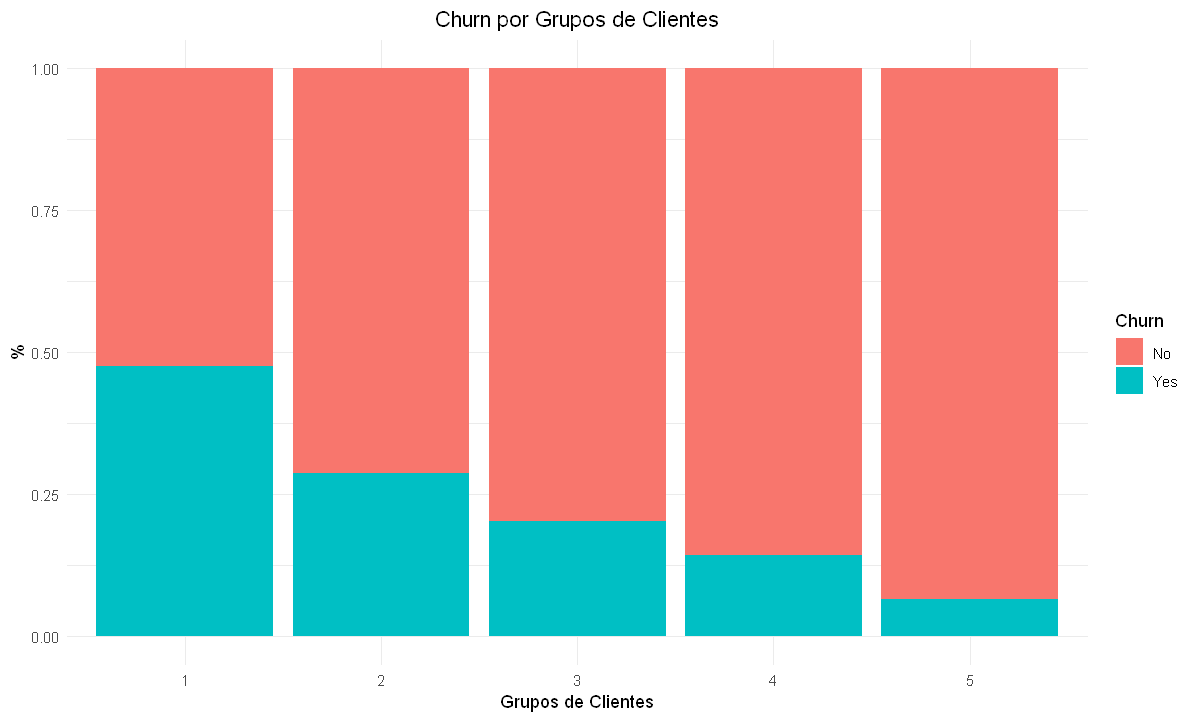

In [25]:
# Churn por grupos de clientes.
df1 %>%
ggplot(aes(x = tenure_group, fill = Churn)) + 
geom_bar(position = 'fill') + 
labs(x = 'Grupos de Clientes',
     y = '%',
     title = 'Churn por Grupos de Clientes') + 
theme(plot.title = element_text(hjust = 0.5))

- Aproximadamente 50% dos clientes com tempo de contrato de até 12 meses cancelaram os serviços da empresa.

### 3.2 Seleção de Variáveis (Feature Selection)

Essa etapa será constituída na análise de correlação e na exclusão de variáveis categóricas que não fornecerão informações úteis para prever o resultado.

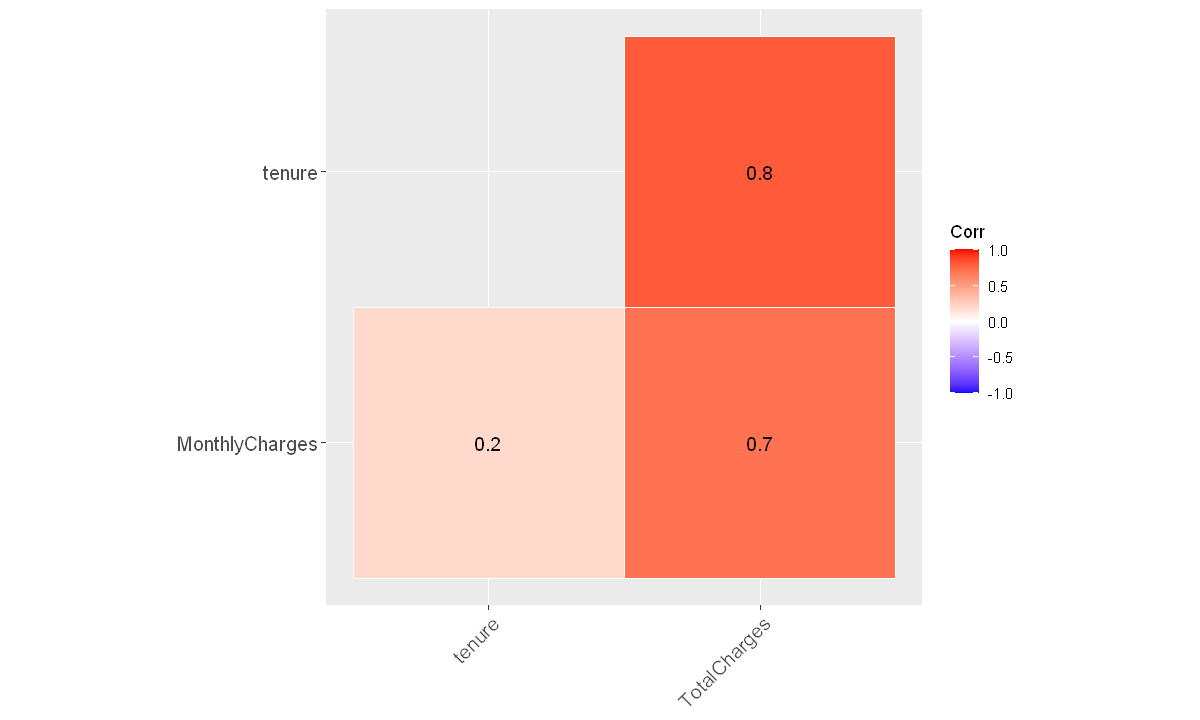

In [26]:
# Análise de correlação.
corr <- round(cor(df1[, c('tenure', 'MonthlyCharges', 'TotalCharges')]), 1)

# Plotagem.
ggcorrplot(corr, 
           hc.order = TRUE, 
           type = 'lower',
           outline.col = 'white',
           ggtheme = ggplot2::theme_gray, 
           lab = TRUE)
colors = c('#6D9EC1', 'white', '#E46726')

Por conta da alta correlação da variável **`TotalCharges`** com as demais variáveis numéricas, a mesma será desconsiderada.

Em relação as variáveis categóricas, vimos durante a análise exploratória que todas elas possuem uma grande diferença em termos percentuais das classes, exceto as variáveis **`gender`**, **`PhoneService`** e **`MultipleLines`**. Sendo assim, essas variáveis também serão desconsideradas. 

Por fim, as variáveis **`customerID`** que se refere a identificação dos clientes e a **`tenure`** que está representada em outra variável também serão descartadas. 

In [27]:
# Seleção de variáveis.
df2 <- subset(df1, select = -c(customerID, gender, tenure, PhoneService, MultipleLines, TotalCharges))

In [28]:
# Visualizando o dataframe.
head(df2)

SeniorCitizen,Partner,Dependents,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,Churn,tenure_group
0,Yes,No,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,No,1
0,No,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,No,3
0,No,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,Yes,1
0,No,No,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,No,3
0,No,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,Yes,1
0,No,No,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,Yes,1


## 4. Pré-Processamento dos Dados

### 4.1 Divisão Treino/Teste

In [29]:
# Divindo os dados.
set.seed(42)
ind <- createDataPartition(df2$Churn, p = .70, list = F)

# Conjuntos de treino e teste.
train <- df2[ind, ]
test  <- df2[-ind, ]

### 4.2 Balanceamento de Classes

O balanceamento de classes é aplicado apenas aos dados de treino.

Vejamos as características do conjunto de treino antes da aplicação.

In [30]:
# Dimensão do conjunto de treino.
dim(train)

[1] 4924   16

In [31]:
# Proporção da variável target.
prop.table(table(train$Churn))


       No       Yes 
0.7341592 0.2658408 

In [32]:
# Balanceando as classes.
train <- ovun.sample(Churn ~ ., data = train, method = 'over')$data

In [33]:
# Dimensão do conjunto de treino.
dim(train)

[1] 7246   16

In [34]:
# Proporção da variável target.
prop.table(table(train$Churn))


       No       Yes 
0.4988959 0.5011041 

### 4.3 Codificação de Variáveis

#### 4.3.1 Conjunto de Treino

Para as variáveis multiclasse, aplicaremos a transformação *One Hot Enconding*.

In [35]:
# Variáveis multiclasse.

# One Hot Enconding.
dummies_model <- dummyVars(Churn ~ InternetService + Contract + PaymentMethod, data = train)

# Aplicando a transformação. 
trainData <- data.frame(predict(dummies_model, newdata = train))

# Adicionando as demais variáveis.
trainData <- cbind(trainData, train)

# Removendo as variáveis transformadas.
trainData <- subset(trainData, select = -c(InternetService, Contract, PaymentMethod))

Para as variáveis binárias, substituiremos os valores *No* e *Yes* por 0 e 1.

In [36]:
# Variáveis binárias.

# Índices das variáveis.
cols_recode <- c(12:20)

# Tratando os registros das variáveis.
for(i in 1: ncol(trainData[, cols_recode])){
    trainData[, cols_recode][,i] <- as.factor(mapvalues(trainData[, cols_recode][,i], from = c('No', 'Yes'), to = c('0', '1')))}

#### 4.3.2 Conjunto de Teste

Aplicaremos as mesmas transformações realizadas no conjunto de treino ao conjunto de teste.

In [37]:
# Variáveis multiclasse.

# One Hot Enconding.
testData <- data.frame(predict(dummies_model, test))

# Adicionando as demais variáveis.
testData <- cbind(testData, test)

# Removendo as variáveis transformadas.
testData <- subset(testData, select = -c(InternetService, Contract, PaymentMethod))

In [38]:
# Variáveis binárias.

# Índices das variáveis.
cols_recode <- c(12:20)

# Tratando os registros das variáveis.
for(i in 1: ncol(testData[, cols_recode])){
    testData[, cols_recode][,i] <- as.factor(mapvalues(testData[, cols_recode][,i], from = c('No', 'Yes'), to = c('0', '1')))}

### 4.4 Normalização de Variáveis

Essa etapa será constituída na normalização da variável **`MonthlyCharges`**.

In [39]:
# Conjunto de treino.
range_model <- preProcess(trainData, method = 'range')

# Aplicando a transformação. 
trainData <- data.frame(predict(range_model, newdata = trainData))

In [40]:
# Conjunto de teste.
testData <- predict(range_model, newdata = testData)

Vejamos o resultado final após os processamentos realizados.

In [41]:
# Conjunto de treino.
str(trainData)

'data.frame':	7246 obs. of  23 variables:
 $ InternetService.DSL                    : num  1 1 1 0 1 1 0 0 0 0 ...
 $ InternetService.Fiber.optic            : num  0 0 0 1 0 0 0 1 1 0 ...
 $ InternetService.No                     : num  0 0 0 0 0 0 1 0 0 1 ...
 $ Contract.Month.to.month                : num  1 0 0 1 0 1 0 0 1 0 ...
 $ Contract.One.year                      : num  0 1 1 0 1 0 0 1 0 1 ...
 $ Contract.Two.year                      : num  0 0 0 0 0 0 1 0 0 0 ...
 $ PaymentMethod.Bank.transfer..automatic.: num  0 0 1 0 1 0 0 0 0 0 ...
 $ PaymentMethod.Credit.card..automatic.  : num  0 0 0 1 0 0 1 1 0 0 ...
 $ PaymentMethod.Electronic.check         : num  1 0 0 0 0 0 0 0 1 0 ...
 $ PaymentMethod.Mailed.check             : num  0 1 0 0 0 1 0 0 0 1 ...
 $ SeniorCitizen                          : Factor w/ 2 levels "0","1": 1 1 1 1 1 1 1 1 1 1 ...
 $ Partner                                : Factor w/ 2 levels "0","1": 2 1 1 1 1 2 1 2 1 1 ...
 $ Dependents                       

In [42]:
# Conjunto de teste.
str(testData)

'data.frame':	2108 obs. of  23 variables:
 $ InternetService.DSL                    : num  0 1 0 0 0 1 0 1 0 0 ...
 $ InternetService.Fiber.optic            : num  1 0 1 1 1 0 0 0 1 1 ...
 $ InternetService.No                     : num  0 0 0 0 0 0 1 0 0 0 ...
 $ Contract.Month.to.month                : num  1 1 0 1 1 0 1 1 1 1 ...
 $ Contract.One.year                      : num  0 0 0 0 0 1 0 0 0 0 ...
 $ Contract.Two.year                      : num  0 0 1 0 0 0 0 0 0 0 ...
 $ PaymentMethod.Bank.transfer..automatic.: num  0 0 0 0 0 0 1 1 0 0 ...
 $ PaymentMethod.Credit.card..automatic.  : num  0 0 1 0 1 0 0 0 0 0 ...
 $ PaymentMethod.Electronic.check         : num  1 0 0 1 0 0 0 0 1 1 ...
 $ PaymentMethod.Mailed.check             : num  0 1 0 0 0 1 0 0 0 0 ...
 $ SeniorCitizen                          : Factor w/ 2 levels "0","1": 1 1 1 1 2 1 1 2 1 1 ...
 $ Partner                                : Factor w/ 2 levels "0","1": 1 1 2 1 2 2 1 1 1 1 ...
 $ Dependents                       

## 5. Modelagem Preditiva

Iremos utilizar os dados de treino para treinar e avaliar o desempenho de alguns algoritmos de classificação, são eles: 

- *Logistic Regression*;
- *Naive Bayes*;
- *Decision Tree*;
- *Random Forest*.

In [43]:
# Configurações da validação cruzada.
control <- trainControl(method = 'cv', number = 5)

In [44]:
# Treinando os modelos.

# Logistic Regression.
modelGLM <- train(Churn ~ ., data = trainData, method = 'glm', trControl = control)

# Naive Bayes.
modelNB <- train(Churn ~ ., data = trainData, method = 'nb', trControl = control)

# Decision Tree. 
modelDT <- train(Churn ~ ., data = trainData, method = 'ctree', trControl = control) 

# Random Forest.
modelRF <- train(Churn ~ ., data = trainData, method = 'rf', trControl = control) 


Call:
summary.resamples(object = results)

Models: GLM, NB, DT, RF 
Number of resamples: 5 

Accuracy 
         Min.   1st Qu.    Median      Mean   3rd Qu.      Max. NA's
GLM 0.7413793 0.7494824 0.7681159 0.7631827 0.7763975 0.7805383    0
NB  0.7280883 0.7425811 0.7460317 0.7462024 0.7508627 0.7634483    0
DT  0.7556936 0.7653554 0.7681159 0.7686990 0.7758621 0.7784679    0
RF  0.8689655 0.8743961 0.8785369 0.8768987 0.8799172 0.8826777    0

Kappa 
         Min.   1st Qu.    Median      Mean   3rd Qu.      Max. NA's
GLM 0.4826149 0.4988810 0.5361875 0.5262759 0.5527190 0.5609769    0
NB  0.4560127 0.4850584 0.4918958 0.4922731 0.5016477 0.5267507    0
DT  0.5112901 0.5306069 0.5361132 0.5373030 0.5516508 0.5568541    0
RF  0.7378353 0.7487136 0.7570034 0.7537160 0.7597510 0.7652766    0


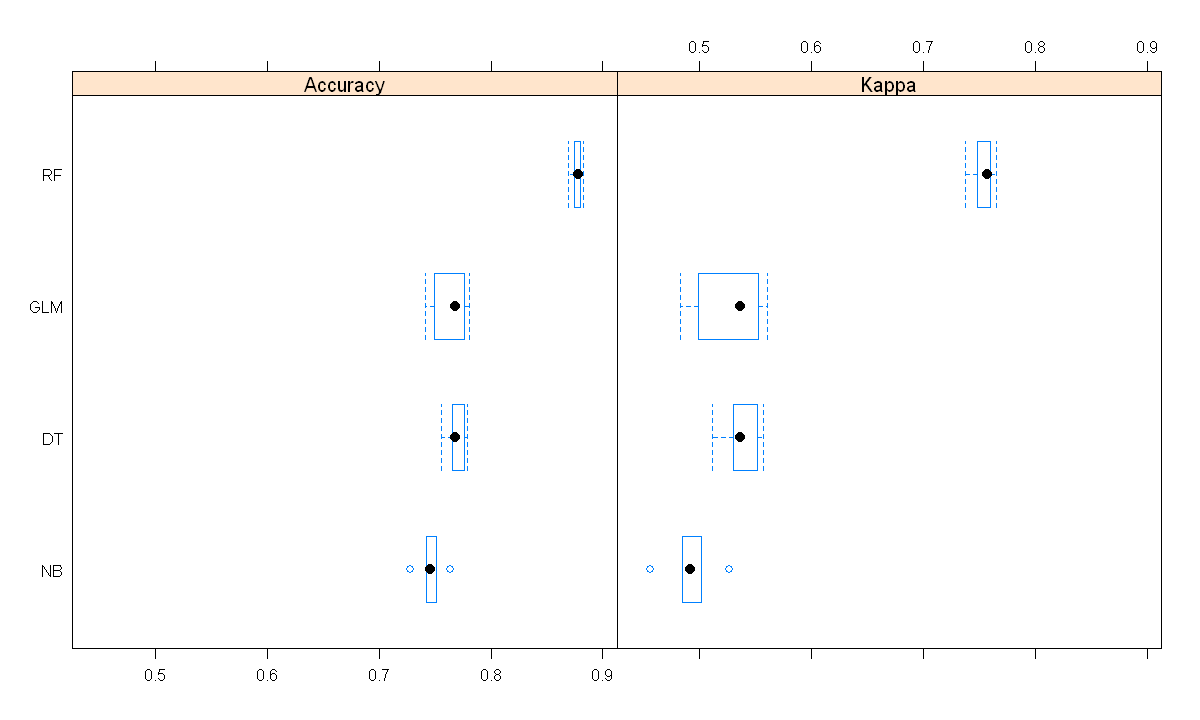

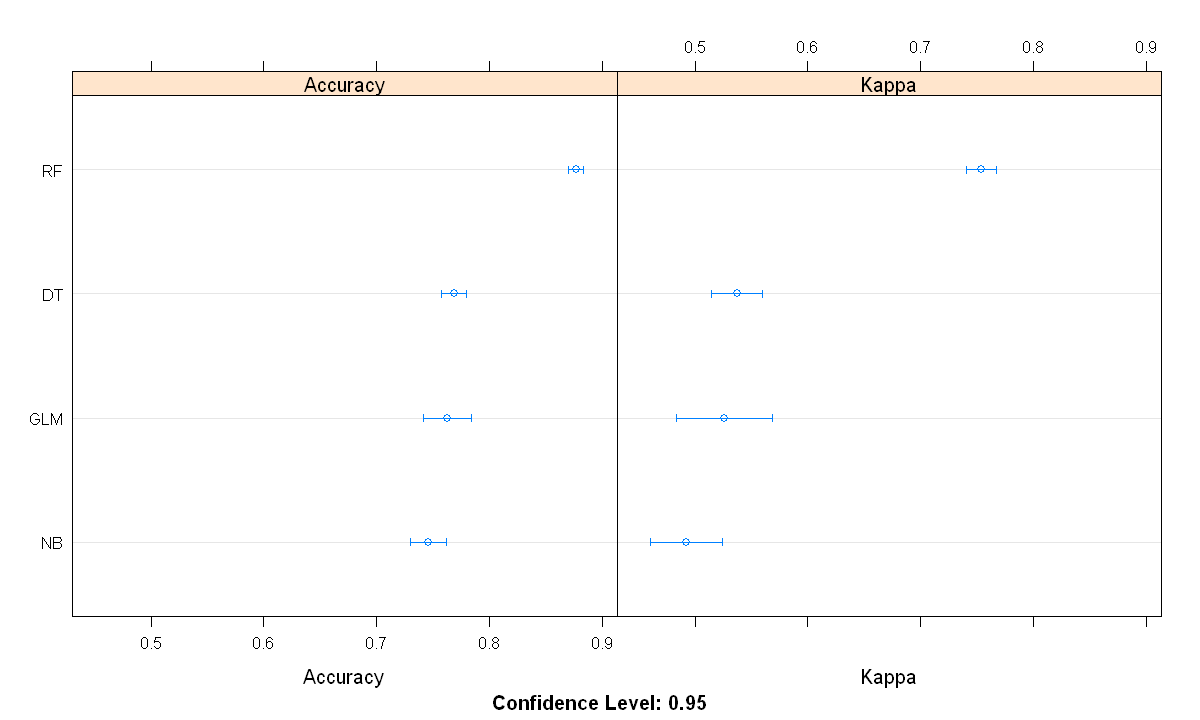

In [45]:
# Obtendo os resultados.
results <- resamples(list(GLM = modelGLM, NB = modelNB, DT = modelDT, RF = modelRF))
summary(results)
bwplot(results)
dotplot(results)

Baseado na acurácia e na métrica *Kappa* (teste de concordância), podemos concluir:

- *RandomForest* teve uma alta performance com os dados de treino, porém, devemos checar a ocorrência de *overfitting*.
- *Logistic Regression* e *Decision Tree* tiveram desempenhos semelhantes. 
- *Naive Bayes* será desconsiderado pois teve a menor performance. 

### 5.1 Random Forest

Vejamos como o modelo treinado se sairá com os dados de teste. Para mais detalhes sobre esse algoritmo acesse <a href='https://medium.com/@rafaelfelippe_/floresta-aleat%C3%B3ria-random-florest-f9b415d582a2'>este link</a>.

In [46]:
# Previsões do modelo.

# Previsões com dados de treino.
rf_train <- predict(modelRF, trainData)

# Previsões com dados de teste.
rf_test <- predict(modelRF, testData)

In [47]:
# Desempenho com dados de treino.
confusionMatrix(rf_train, trainData$Churn, positive = 'Yes', mode = 'everything')

Confusion Matrix and Statistics

          Reference
Prediction   No  Yes
       No  3472   10
       Yes  143 3621
                                               
               Accuracy : 0.9789               
                 95% CI : (0.9753, 0.9821)     
    No Information Rate : 0.5011               
    P-Value [Acc > NIR] : < 0.00000000000000022
                                               
                  Kappa : 0.9578               
                                               
 Mcnemar's Test P-Value : < 0.00000000000000022
                                               
            Sensitivity : 0.9972               
            Specificity : 0.9604               
         Pos Pred Value : 0.9620               
         Neg Pred Value : 0.9971               
              Precision : 0.9620               
                 Recall : 0.9972               
                     F1 : 0.9793               
             Prevalence : 0.5011               
         Detection R

In [48]:
# Desempenho com dados de teste.
confusionMatrix(rf_test, test$Churn, positive = 'Yes', mode = 'everything')

Confusion Matrix and Statistics

          Reference
Prediction   No  Yes
       No  1277  212
       Yes  271  348
                                          
               Accuracy : 0.7709          
                 95% CI : (0.7523, 0.7887)
    No Information Rate : 0.7343          
    P-Value [Acc > NIR] : 0.00006471      
                                          
                  Kappa : 0.4318          
                                          
 Mcnemar's Test P-Value : 0.008313        
                                          
            Sensitivity : 0.6214          
            Specificity : 0.8249          
         Pos Pred Value : 0.5622          
         Neg Pred Value : 0.8576          
              Precision : 0.5622          
                 Recall : 0.6214          
                     F1 : 0.5903          
             Prevalence : 0.2657          
         Detection Rate : 0.1651          
   Detection Prevalence : 0.2936          
      Balanced Accuracy 

Apesar do bom desempenho, observamos que esse modelo está sobreajustado.

### 5.2 Logistic Regression

Para saber como esse algoritmo funciona, acesse <a href='https://medium.com/@rafaelfelippe_/regress%C3%A3o-log%C3%ADstica-logistic-regression-7f3f19319bd3'>esse link</a> em meu blog de estudos.

In [49]:
# Previsões do modelo.

# Previsões com dados de treino.
glm_train <- predict(modelGLM, trainData)

# Previsões com dados de teste.
glm_test <- predict(modelGLM, testData)

In [50]:
# Desempenho com dados de treino.
confusionMatrix(glm_train, trainData$Churn, positive = 'Yes', mode = 'everything')

Confusion Matrix and Statistics

          Reference
Prediction   No  Yes
       No  2613  702
       Yes 1002 2929
                                               
               Accuracy : 0.7648               
                 95% CI : (0.7549, 0.7746)     
    No Information Rate : 0.5011               
    P-Value [Acc > NIR] : < 0.00000000000000022
                                               
                  Kappa : 0.5296               
                                               
 Mcnemar's Test P-Value : 0.0000000000004379   
                                               
            Sensitivity : 0.8067               
            Specificity : 0.7228               
         Pos Pred Value : 0.7451               
         Neg Pred Value : 0.7882               
              Precision : 0.7451               
                 Recall : 0.8067               
                     F1 : 0.7747               
             Prevalence : 0.5011               
         Detection R

In [51]:
# Desempenho com dados de teste.
confusionMatrix(glm_test, test$Churn, positive = 'Yes', mode = 'everything')

Confusion Matrix and Statistics

          Reference
Prediction   No  Yes
       No  1138  103
       Yes  410  457
                                              
               Accuracy : 0.7566              
                 95% CI : (0.7377, 0.7748)    
    No Information Rate : 0.7343              
    P-Value [Acc > NIR] : 0.01044             
                                              
                  Kappa : 0.4691              
                                              
 Mcnemar's Test P-Value : < 0.0000000000000002
                                              
            Sensitivity : 0.8161              
            Specificity : 0.7351              
         Pos Pred Value : 0.5271              
         Neg Pred Value : 0.9170              
              Precision : 0.5271              
                 Recall : 0.8161              
                     F1 : 0.6405              
             Prevalence : 0.2657              
         Detection Rate : 0.2168      

- O modelo performou bem em ambos os conjuntos, com uma acurácia de aproximadamente 75%.
- No conjunto de teste, observamos uma maior dificuldade ao classificar registros da classe positiva.

Caso desejado, podemos treinar um novo modelo filtrando apenas as melhores variáveis. 

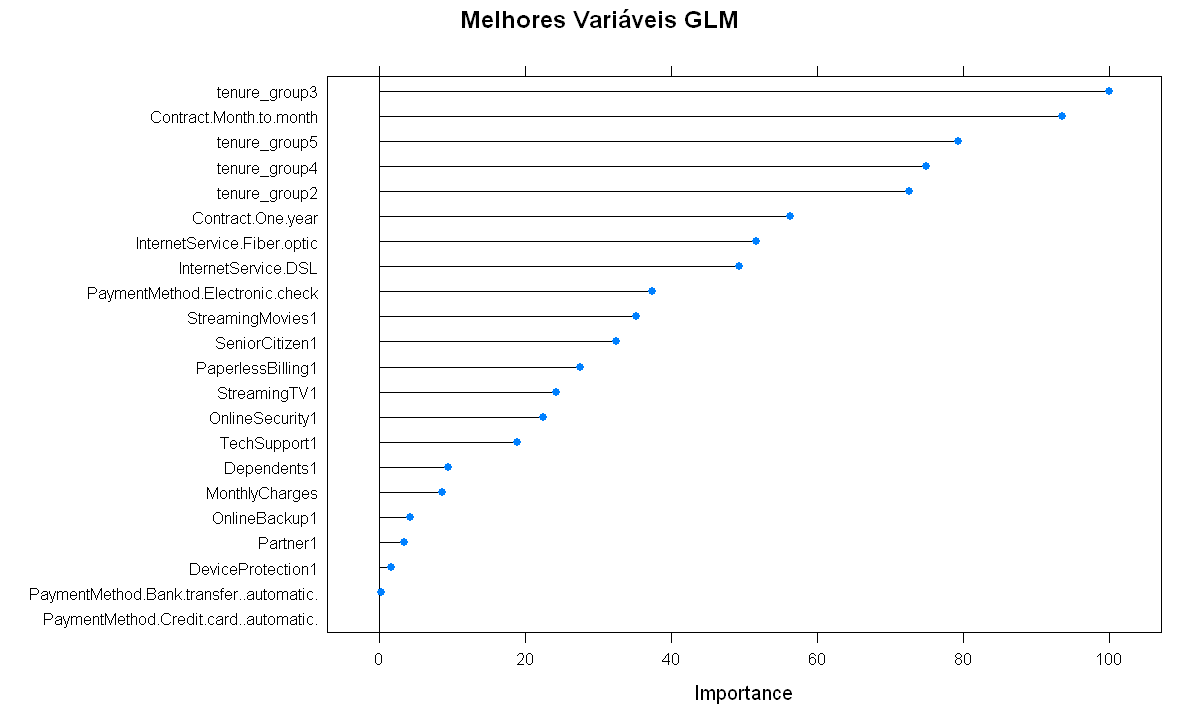

In [52]:
# Variáveis mais importantes.
varImp <- varImp(modelGLM)
plot(varImp, main = 'Melhores Variáveis GLM')

### 5.3 Decision Tree

Realizaremos o mesmo procedimento abordado com os outros algoritmos.

In [53]:
# Previsões do modelo.

# Previsões com dados de treino.
dt_train <- predict(modelDT, trainData)

# Previsões com dados de teste.
dt_test <- predict(modelDT, testData)

In [54]:
# Desempenho com dados de treino.
confusionMatrix(dt_train, trainData$Churn, positive = 'Yes', mode = 'everything')

Confusion Matrix and Statistics

          Reference
Prediction   No  Yes
       No  2869  535
       Yes  746 3096
                                               
               Accuracy : 0.8232               
                 95% CI : (0.8142, 0.8319)     
    No Information Rate : 0.5011               
    P-Value [Acc > NIR] : < 0.00000000000000022
                                               
                  Kappa : 0.6464               
                                               
 Mcnemar's Test P-Value : 0.000000004427       
                                               
            Sensitivity : 0.8527               
            Specificity : 0.7936               
         Pos Pred Value : 0.8058               
         Neg Pred Value : 0.8428               
              Precision : 0.8058               
                 Recall : 0.8527               
                     F1 : 0.8286               
             Prevalence : 0.5011               
         Detection R

In [55]:
# Desempenho com dados de teste.
confusionMatrix(dt_test, test$Churn, positive = 'Yes', mode = 'everything')

Confusion Matrix and Statistics

          Reference
Prediction   No  Yes
       No  1165  159
       Yes  383  401
                                             
               Accuracy : 0.7429             
                 95% CI : (0.7237, 0.7614)   
    No Information Rate : 0.7343             
    P-Value [Acc > NIR] : 0.1943             
                                             
                  Kappa : 0.4156             
                                             
 Mcnemar's Test P-Value : <0.0000000000000002
                                             
            Sensitivity : 0.7161             
            Specificity : 0.7526             
         Pos Pred Value : 0.5115             
         Neg Pred Value : 0.8799             
              Precision : 0.5115             
                 Recall : 0.7161             
                     F1 : 0.5967             
             Prevalence : 0.2657             
         Detection Rate : 0.1902             
   Detecti

Assim como na *Random Forest*, esse modelo também apresentou sobreajuste nos dados.

Com isso, finalizamos a etapa de modelagem preditiva.

## 6. Comparando os Modelos

Para comparar os modelos utilizaremos a Curva *ROC* e a *AUC* que são ferramentas para medir o desempenho de modelos de classificação binária. 

Abaixo segue uma breve explicação do que cada uma representa:

- ***ROC***: é uma curva de probabilidade. Ela é criada traçando a taxa de verdadeiros positivos contra a taxa de falsos positivos, ou seja, número de vezes que o classificador acertou a predição contra o número de vezes que o classificador errou a predição.


- ***AUC*** representa uma medida de separabilidade. Quanto maior o *AUC*, melhor o modelo está em prever as classes corretamente.

In [56]:
# Previsões em probabilidades.
dt_pb <- predict(modelDT, testData, type = 'prob')[,2]
glm_pb <- predict(modelGLM, testData, type = 'prob')[,2]
rf_pb <- predict(modelRF, testData, type = 'prob')[,2]

In [57]:
# Concatenando os dados.
roc.data <- cbind(testData, dt_pb, glm_pb, rf_pb)
head(roc.data[, c('Churn', 'dt_pb', 'glm_pb', 'rf_pb')])

,Churn,dt_pb,glm_pb,rf_pb
6,Yes,0.98076923,0.91767440,0.978
8,No,0.61764706,0.55198729,0.912
16,No,0.03478261,0.06004441,0.086
20,No,0.66666667,0.77068851,0.422
32,No,0.75789474,0.90399770,0.822
33,No,0.07692308,0.06820508,0.126


In [58]:
# Preparando os dados.
roc.long <- melt_roc(roc.data, d = 'Churn', m = c('dt_pb', 'glm_pb', 'rf_pb'))

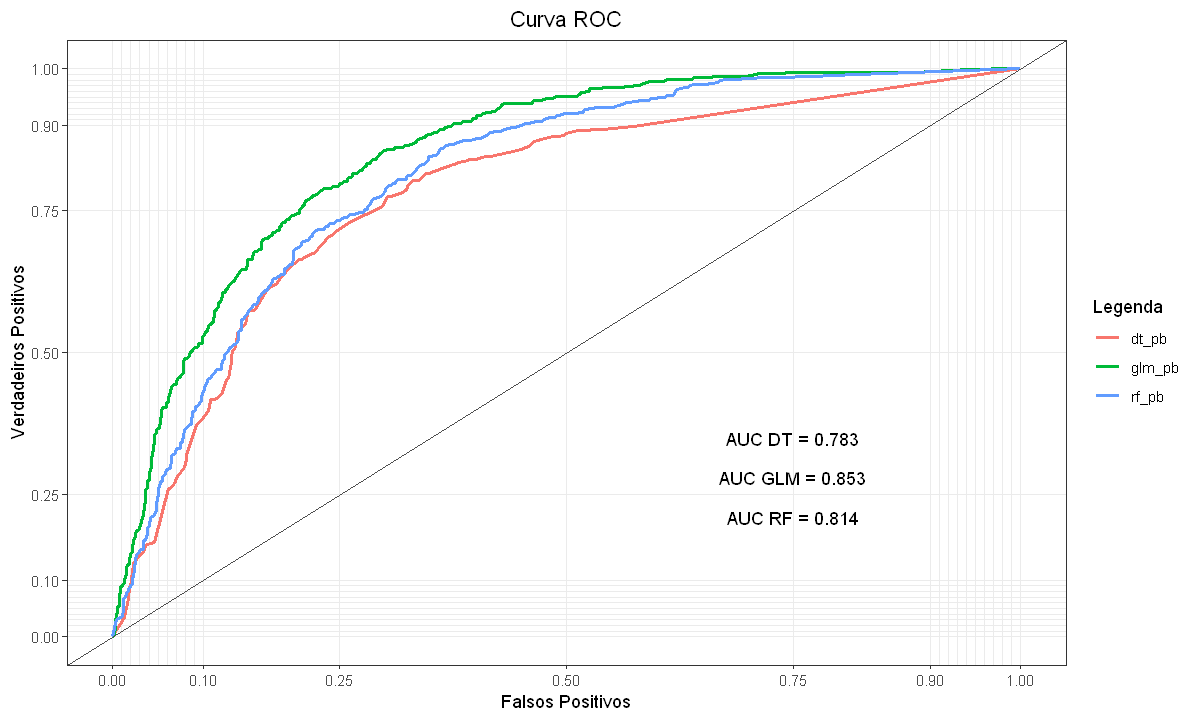

In [59]:
# ROC AUC.
rocplot <- ggplot(roc.long, aes(d = ifelse(D == 'Yes', 1, 0), m = M, color = name)) +
geom_roc(n.cuts = 0) +
style_roc(xlab = 'Falsos Positivos',
          ylab = 'Verdadeiros Positivos') +
labs(title = 'Curva ROC', color = 'Legenda') +
theme(plot.title = element_text(hjust = 0.5))

# Plotagem.
rocplot +
geom_abline(size = 0.5, color = 'grey30') +
annotate('text', x = .75, y = .35, label = paste('AUC DT =', round(calc_auc(rocplot)$AUC[1],3))) +
annotate('text', x = .75, y = .28, label = paste('AUC GLM =', round(calc_auc(rocplot)$AUC[2],3))) +
annotate('text', x = .75, y = .21, label = paste('AUC RF =', round(calc_auc(rocplot)$AUC[3],3)))

## 7. Conclusões Finais

Os modelos treinados com a *Random Forest* e a Regressão Logística foram os que apresentaram os melhores resultados. Para a entrega final desse primeiro ciclo, optamos pelo modelo com a Regressão Logística, pois esse obteve um resultado semelhante ao primeiro, e está mais generalizável. Abaixo segue as métricas do modelo com os dados de teste:

- **Accuracy**: 75,6% de acerto considerando ambas as classes. 
- **Precision**: 52,7% dos registros da classe positiva foram classificados corretamente.         
- **Recall**: 81,6% das previsões feitas para a classe positiva estão corretas.          
- **F1**: 64%, média harmônica entre *precision* e *recall*.   

Para um primeiro ciclo do projeto, esses resultados são satisfatórios, porém, podemos perceber que há uma dificuldade do modelo em prever a classe positiva, e isso, deverá ser considerado para um próximo ciclo. Nesse caso, algumas tarefas que poderiam ajudar são: 

- Aumentar a quantidade de registros da classe positiva para o treinamento do modelo.
- Avaliar outros métodos de balanceamento de classes. 

Além disso, também poderia ser realizado: 

- Treinamento do modelo considerando apenas as melhores variáveis. 
- Otimização dos hiperparâmetros do modelo.
- Avaliação de outros classificadores.

Implementando essa primeira versão do modelo, a EasyNet conseguirá identificar em média 52,7% dos clientes que abandonarão os serviços da empresa.